# Business Case:To predict the flight fare by using given features of the data

accurately forecasting flight ticket prices

In [1]:
#importing the .
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# uploading the dataset
df=pd.read_csv('Clean_Dataset.csv')
df

In [3]:
#Basic checks
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [4]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [5]:
df.describe(include='O')

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


In [6]:
df.dtypes

Unnamed: 0            int64
airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object

In [7]:
df.isnull().sum()

Unnamed: 0          0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [8]:
df.nunique()

Unnamed: 0          300153
airline                  6
flight                1561
source_city              6
departure_time           6
stops                    3
arrival_time             6
destination_city         6
class                    2
duration               476
days_left               49
price                12157
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.drop(columns={'Unnamed: 0'},inplace=True)

In [11]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

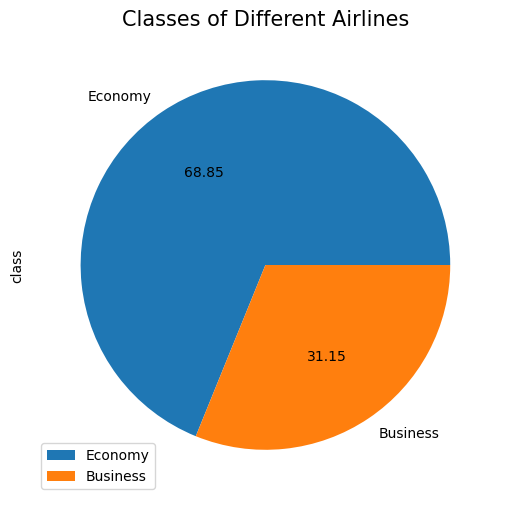

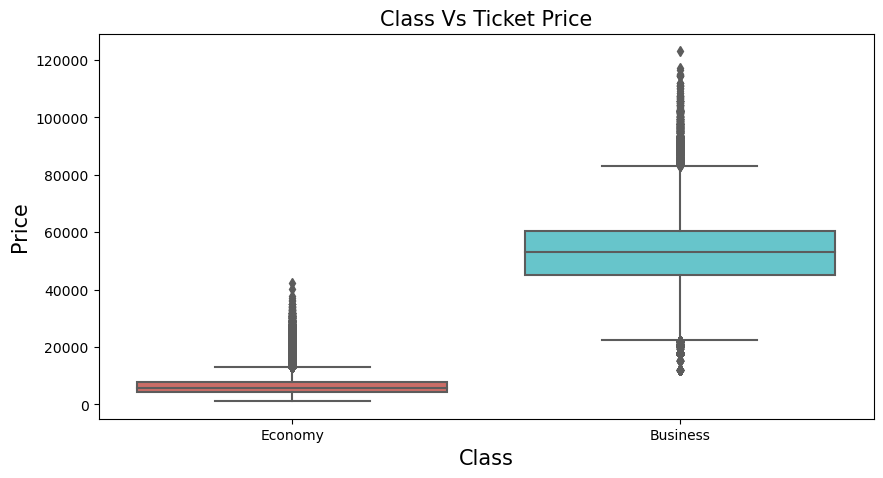

In [12]:
plt.figure(figsize=(8,6))
df['class'].value_counts().plot(kind='pie',textprops={'color':'black'},autopct='%.2f')
plt.title('Classes of Different Airlines',fontsize=15)
plt.legend(['Economy','Business'])
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='class',y='price',data=df,palette='hls')
plt.title('Class Vs Ticket Price',fontsize=15)
plt.xlabel('Class',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

In [13]:
df_economy=df[df['class']=='Economy']
df_economy.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


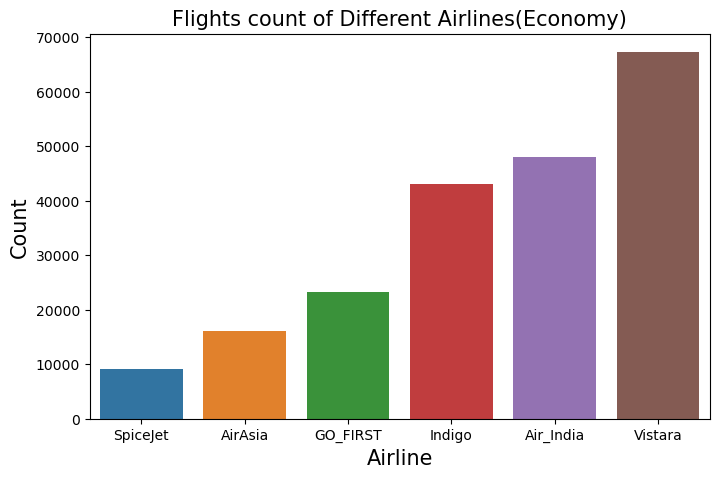

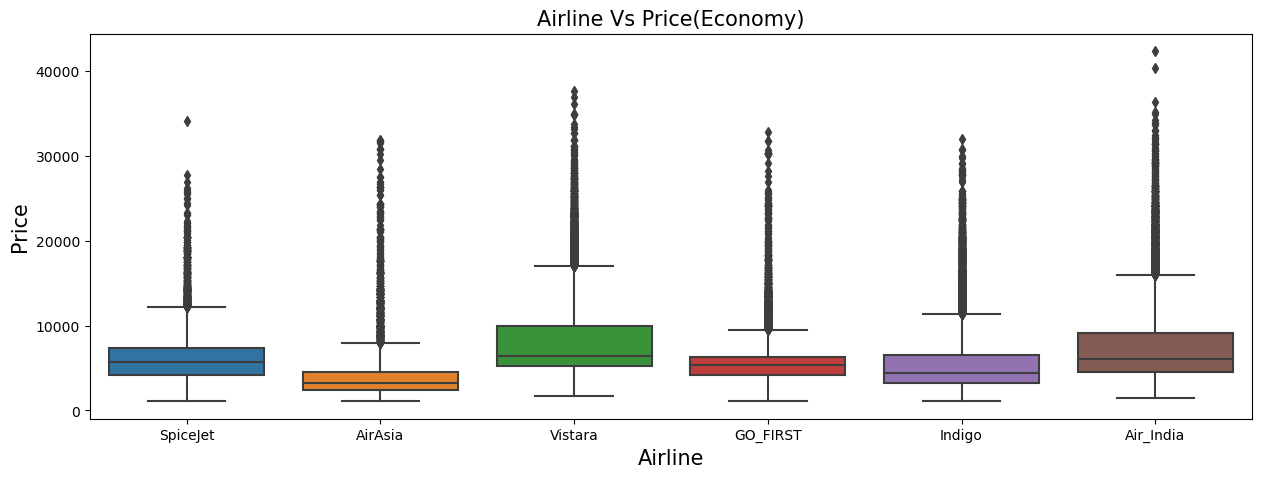

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_economy,x='airline',order=df_economy['airline'].value_counts().index[::-1])
plt.title('Flights count of Different Airlines(Economy)',fontsize=15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Count',fontsize=15)
plt.show()

plt.figure(figsize=(15,5))
sns.boxplot(x='airline',y='price',data=df_economy)
plt.title('Airline Vs Price(Economy)',fontsize=15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

In [15]:
df_business=df[df['class']=='Business']
df_business.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
206666,Air_India,AI-868,Delhi,Evening,zero,Evening,Mumbai,Business,2.00,1,25612
206667,Air_India,AI-624,Delhi,Evening,zero,Night,Mumbai,Business,2.25,1,25612
206668,Air_India,AI-531,Delhi,Evening,one,Night,Mumbai,Business,24.75,1,42220
206669,Air_India,AI-839,Delhi,Night,one,Night,Mumbai,Business,26.50,1,44450
206670,Air_India,AI-544,Delhi,Evening,one,Night,Mumbai,Business,6.67,1,46690


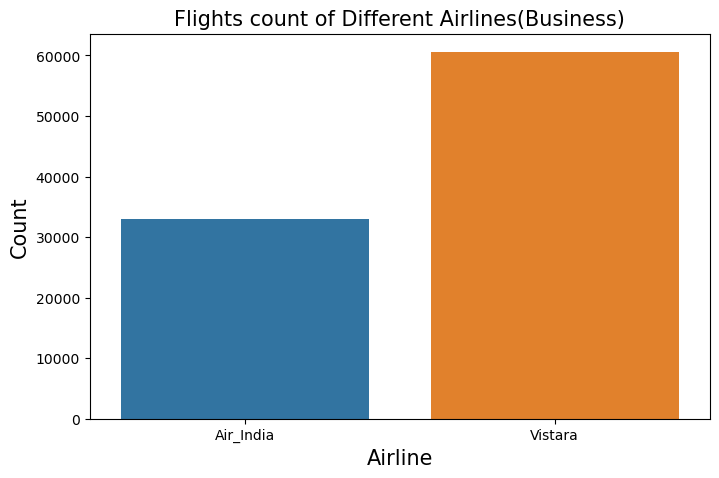

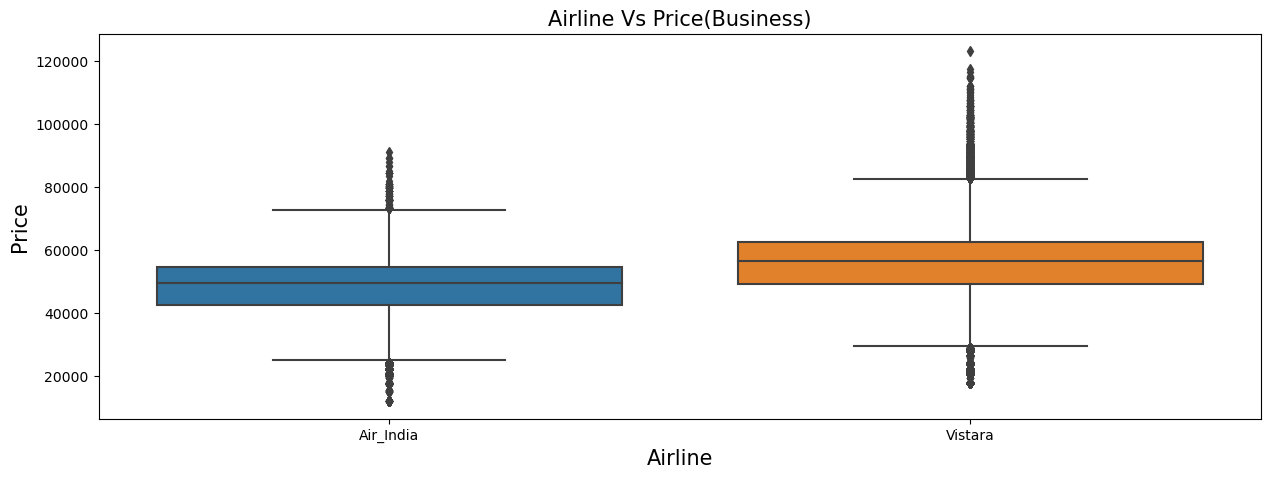

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_business,x='airline',order=df_business['airline'].value_counts().index[::-1])
plt.title('Flights count of Different Airlines(Business)',fontsize=15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Count',fontsize=15)
plt.show()

plt.figure(figsize=(15,5))
sns.boxplot(x='airline',y='price',data=df_business)
plt.title('Airline Vs Price(Business)',fontsize=15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

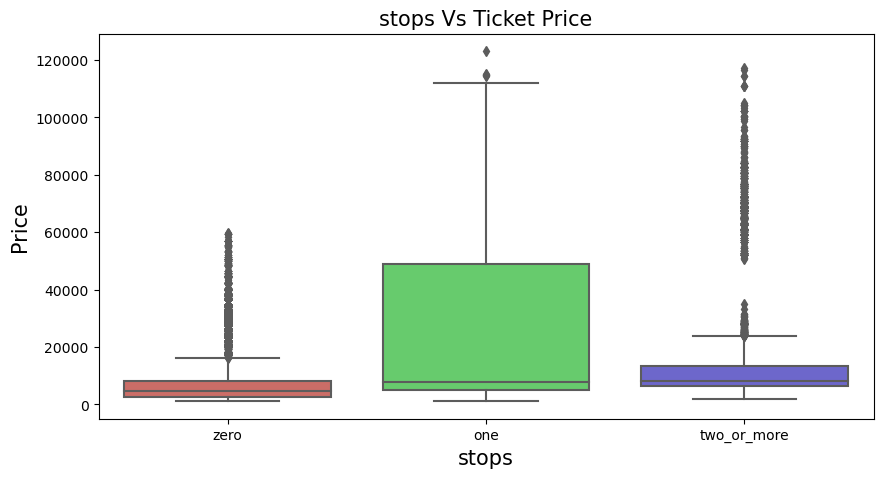

In [17]:
plt.figure(figsize=(10,5))
sns.boxplot(x='stops',y='price',data=df,palette='hls')
plt.title('stops Vs Ticket Price',fontsize=15)
plt.xlabel('stops',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

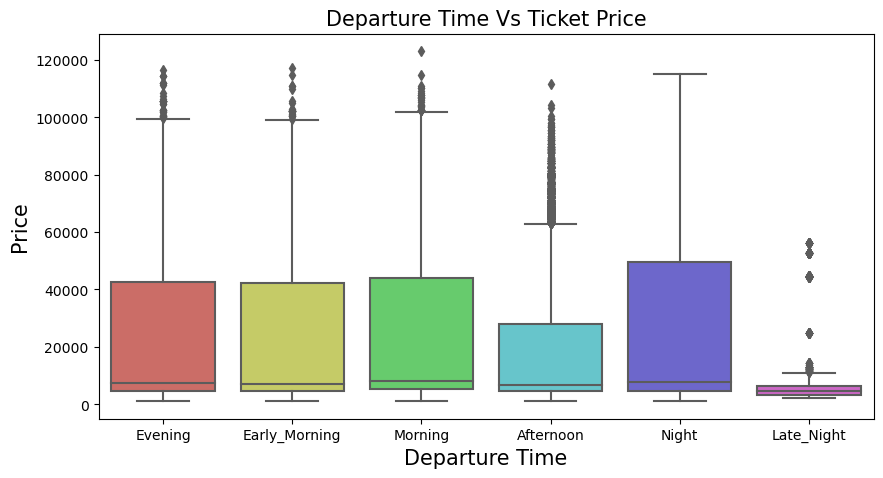

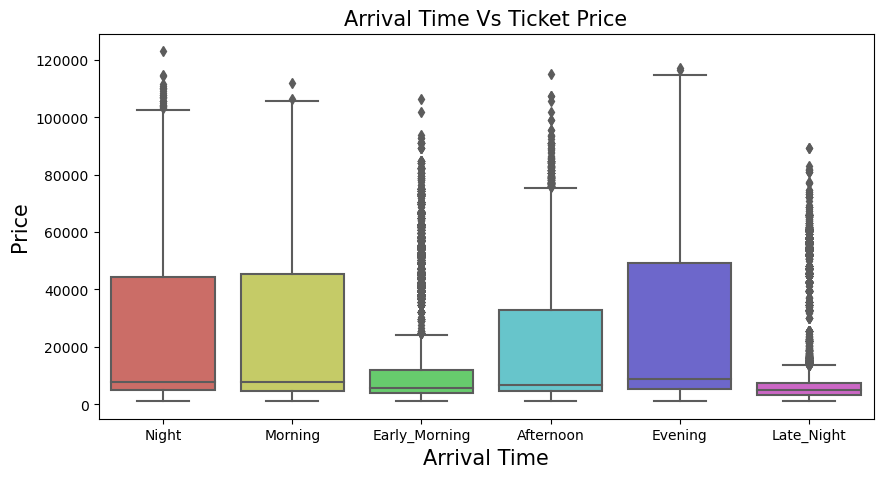

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(x='departure_time',y='price',data=df,palette='hls')
plt.title('Departure Time Vs Ticket Price',fontsize=15)
plt.xlabel('Departure Time',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()


plt.figure(figsize=(10,5))
sns.boxplot(x='arrival_time',y='price',data=df,palette='hls')
plt.title('Arrival Time Vs Ticket Price',fontsize=15)
plt.xlabel('Arrival Time',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

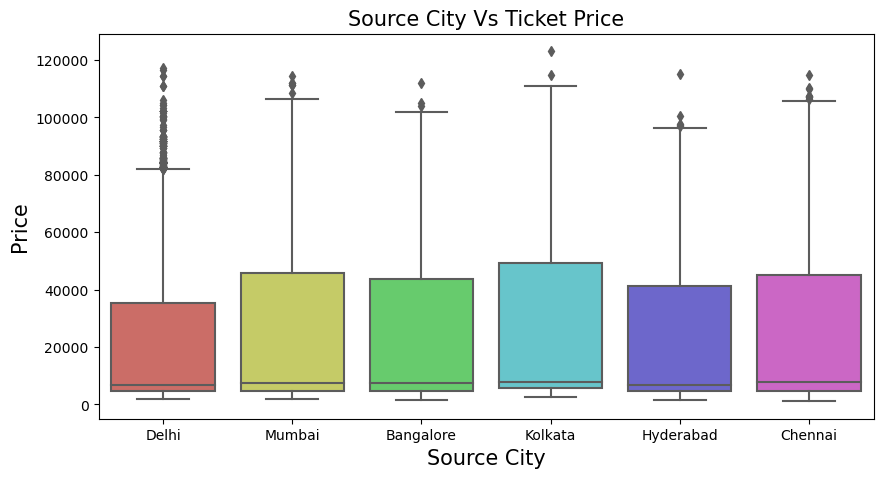

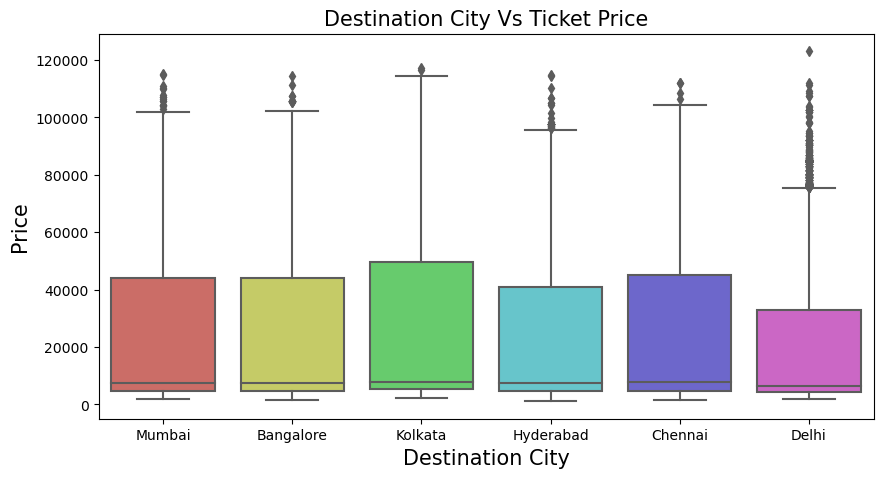

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x='source_city',y='price',data=df,palette='hls')
plt.title('Source City Vs Ticket Price',fontsize=15)
plt.xlabel('Source City',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='destination_city',y='price',data=df,palette='hls')
plt.title('Destination City Vs Ticket Price',fontsize=15)
plt.xlabel('Destination City',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

In [20]:
total_combination=df.groupby(['source_city','destination_city']).agg(combination_count=('price','size'),
                                                                     avg_price=('price','mean')).reset_index()
total_combination['route_name']=total_combination['source_city'].str[0]+total_combination['destination_city'].str[0]
total_combination=total_combination.sort_values(by='combination_count',ascending=False)
print(total_combination)

   source_city destination_city  combination_count     avg_price route_name
14       Delhi           Mumbai              15289  19355.829812         DM
27      Mumbai            Delhi              14809  18725.320008         MD
10       Delhi        Bangalore              14012  17880.216315         DB
1    Bangalore            Delhi              13756  17723.313972         BD
4    Bangalore           Mumbai              12939  23128.618672         BM
25      Mumbai        Bangalore              12885  23147.873807         MB
29      Mumbai          Kolkata              12602  22379.146723         MK
13       Delhi          Kolkata              11934  20566.409418         DK
24     Kolkata           Mumbai              11467  22078.883579         KM
11       Delhi          Chennai              10780  19369.881354         DC
22     Kolkata            Delhi              10506  19422.354559         KD
28      Mumbai        Hyderabad              10470  21004.046705         MH
26      Mumb

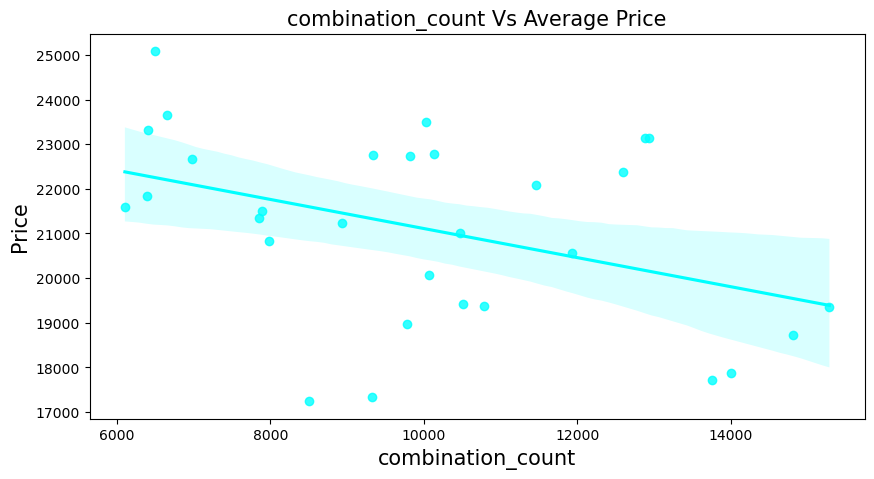

In [21]:
plt.figure(figsize=(10,5))
sns.regplot(x='combination_count',y='avg_price',data=total_combination,color='cyan')
plt.title('combination_count Vs Average Price',fontsize=15)
plt.xlabel('combination_count',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

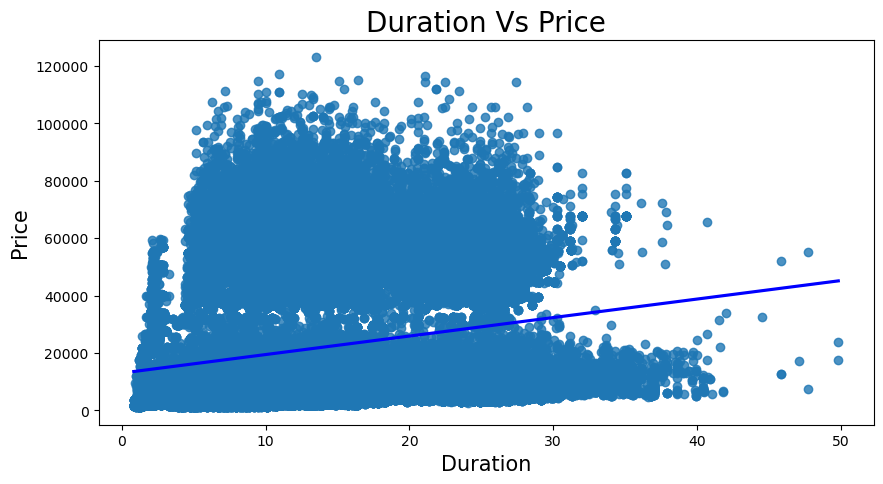

In [22]:
plt.figure(figsize=(10,5))
sns.regplot(x='duration',y='price',data=df,line_kws={'color':'blue'})
plt.title('Duration Vs Price',fontsize=20)
plt.xlabel('Duration',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

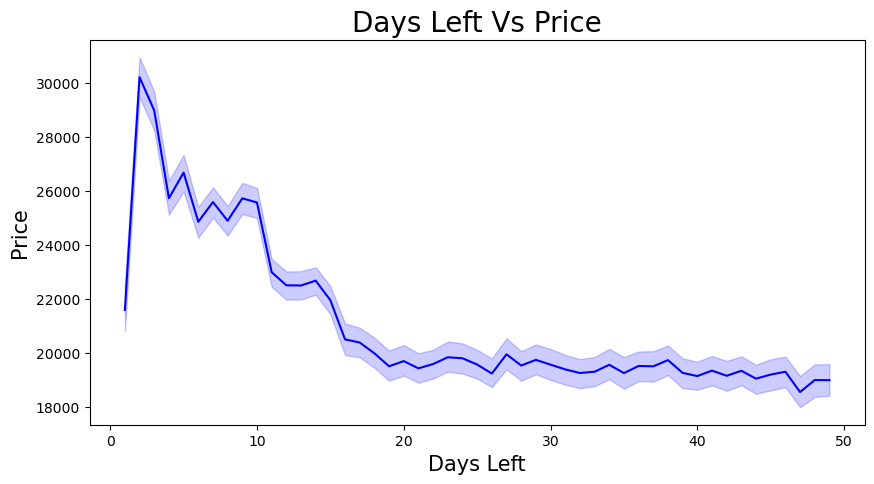

In [23]:
plt.figure(figsize=(10,5))
sns.lineplot(x='days_left',y='price',data=df,color='blue')
plt.title('Days Left Vs Price',fontsize=20)
plt.xlabel('Days Left',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

In [24]:
df_1=df.copy()

In [25]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
import statsmodels.api as sm
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=le.fit_transform(df[col])
        
X=df.drop('price',axis=1)
X=sm.add_constant(X)
y=df['price']
lin_reg=sm.OLS(y,X).fit()
print(lin_reg.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                 2.847e+05
Date:                Tue, 19 Dec 2023   Prob (F-statistic):               0.00
Time:                        21:02:46   Log-Likelihood:            -3.0838e+06
No. Observations:              300153   AIC:                         6.168e+06
Df Residuals:                  300142   BIC:                         6.168e+06
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             5.044e+04     70.966  

In [26]:
X=df.drop(['price'],axis=1)
y=df['price']

In [27]:
X

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
0,4,1408,2,2,2,5,5,1,2.17,1
1,4,1387,2,1,2,4,5,1,2.33,1
2,0,1213,2,1,2,1,5,1,2.17,1
3,5,1559,2,4,2,0,5,1,2.25,1
4,5,1549,2,4,2,4,5,1,2.33,1
...,...,...,...,...,...,...,...,...,...,...
300148,5,1477,1,4,0,2,3,0,10.08,49
300149,5,1481,1,0,0,5,3,0,10.42,49
300150,5,1486,1,1,0,5,3,0,13.83,49
300151,5,1483,1,1,0,2,3,0,10.00,49


In [28]:
y

0          5953
1          5953
2          5956
3          5955
4          5955
          ...  
300148    69265
300149    77105
300150    79099
300151    81585
300152    81585
Name: price, Length: 300153, dtype: int64

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.2)

In [30]:
X_train.shape

(240122, 10)

In [31]:
X_test.shape

(60031, 10)

In [32]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [33]:
y_pred=model.predict(X_test)
y_pred

array([ 4567.01341606, 52844.3396735 ,  7904.94955226, ...,
        5843.83528502, -1684.52051377, 58731.61105007])

In [34]:
y_test

27131      7366
266857    64831
141228     6195
288329    60160
97334      6578
          ...  
5234       5026
5591       3001
168314     6734
175191     5082
287693    66465
Name: price, Length: 60031, dtype: int64

In [35]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.9045747930770209
4622.187103361351
49190002.62043739


In [36]:
from sklearn.preprocessing import MinMaxScaler
MMS=MinMaxScaler()
X_train_MMS=MMS.fit_transform(X_train)
X_train_MMS 

array([[0.2       , 0.45769231, 0.8       , ..., 1.        , 0.37938776,
        0.10416667],
       [0.6       , 0.07051282, 0.4       , ..., 1.        , 0.12591837,
        0.25      ],
       [0.2       , 0.54166667, 0.8       , ..., 0.        , 0.41510204,
        0.89583333],
       ...,
       [0.2       , 0.54230769, 0.8       , ..., 1.        , 0.26204082,
        0.58333333],
       [0.4       , 0.59230769, 0.8       , ..., 1.        , 0.15306122,
        0.79166667],
       [0.2       , 0.53397436, 0.8       , ..., 1.        , 0.39469388,
        0.33333333]])

In [37]:
X_test_MMS=MMS.fit_transform(X_test)
X_test_MMS

array([[0.2       , 0.47948718, 0.4       , ..., 1.        , 0.40323956,
        0.8125    ],
       [1.        , 0.92435897, 0.8       , ..., 0.        , 0.19181586,
        0.85416667],
       [1.        , 0.93205128, 0.8       , ..., 1.        , 0.20609548,
        0.83333333],
       ...,
       [0.2       , 0.49423077, 0.6       , ..., 1.        , 0.27173913,
        0.5625    ],
       [0.6       , 0.10769231, 0.6       , ..., 1.        , 0.02493606,
        0.8125    ],
       [1.        , 0.94807692, 0.2       , ..., 0.        , 0.52408355,
        0.04166667]])

In [38]:
y_train

148417    13524
36879      9940
274531    55983
166397     7927
272722    55502
          ...  
119879    22869
259178    44280
131932     5102
146867     5574
121958     6339
Name: price, Length: 240122, dtype: int64

In [39]:
y_test

27131      7366
266857    64831
141228     6195
288329    60160
97334      6578
          ...  
5234       5026
5591       3001
168314     6734
175191     5082
287693    66465
Name: price, Length: 60031, dtype: int64

In [42]:
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor()
rfr.fit(X_train,y_train)

RandomForestRegressor()

In [47]:
y_pred=rfr.predict(X_test)
y_pred

array([ 7338.41, 71193.72,  6195.  , ...,  6469.4 ,  3811.18, 70196.71])

In [48]:
y_test

27131      7366
266857    64831
141228     6195
288329    60160
97334      6578
          ...  
5234       5026
5591       3001
168314     6734
175191     5082
287693    66465
Name: price, Length: 60031, dtype: int64

In [49]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.9895722918756217
864.0071578053718
5375298.692067164


In [53]:
from sklearn.tree import DecisionTreeRegressor
dtr=DecisionTreeRegressor()
dtr.fit(X_train,y_train)

DecisionTreeRegressor()

In [54]:
y_pred=dtr.predict(X_test)
y_pred

array([ 7366., 72783.,  6195., ...,  6734.,  2815., 70049.])

In [55]:
y_test

27131      7366
266857    64831
141228     6195
288329    60160
97334      6578
          ...  
5234       5026
5591       3001
168314     6734
175191     5082
287693    66465
Name: price, Length: 60031, dtype: int64

In [56]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.9827022556544537
895.3976723137491
8916680.582855338


In [57]:
rfr.fit(X_train,y_train)
y_pred=rfr.predict(X_test)

In [58]:
out=pd.DataFrame({'Price_actual':y_test,'Price_pred':y_pred})
result=df_1.merge(out,left_index=True,right_index=True)
result.sample(20)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,Price_actual,Price_pred
158505,Air_India,AI-616,Hyderabad,Morning,one,Evening,Delhi,Economy,9.92,49,4387,4387,4387.00
245654,Vistara,UK-852,Bangalore,Morning,one,Evening,Delhi,Business,8.58,12,54841,54841,55546.60
126936,Air_India,AI-773,Kolkata,Evening,one,Night,Delhi,Economy,27.58,46,5467,5467,5642.61
277013,Air_India,AI-525,Hyderabad,Early_Morning,one,Night,Delhi,Business,16.75,45,47586,47586,47586.00
183333,SpiceJet,SG-678,Chennai,Early_Morning,one,Afternoon,Delhi,Economy,6.25,23,4048,4048,4048.00
6354,Vistara,UK-819,Delhi,Afternoon,one,Night,Mumbai,Economy,6.50,32,6296,6296,6296.00
245432,Vistara,UK-802,Bangalore,Evening,zero,Night,Delhi,Business,2.75,10,32923,32923,34180.31
280997,Vistara,UK-860,Hyderabad,Early_Morning,one,Evening,Bangalore,Business,12.00,15,56702,56702,56702.00
56233,GO_FIRST,G8-575,Mumbai,Early_Morning,one,Afternoon,Bangalore,Economy,10.25,21,4750,4750,4194.19
56041,Indigo,6E-5308,Mumbai,Afternoon,one,Night,Bangalore,Economy,6.75,20,4284,4284,4467.67


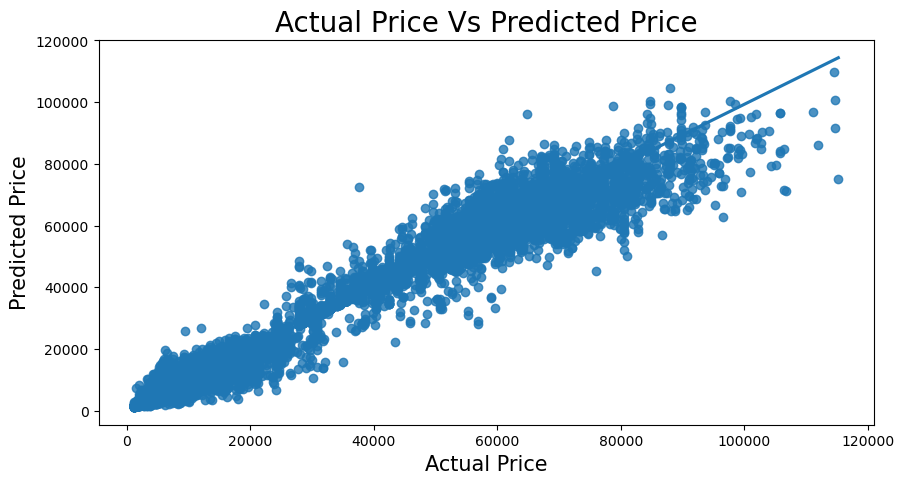

In [60]:
plt.figure(figsize=(10,5))
sns.regplot(x='Price_actual',y='Price_pred',data=result)
plt.title('Actual Price Vs Predicted Price',fontsize=20)
plt.xlabel('Actual Price',fontsize=15)
plt.ylabel('Predicted Price',fontsize=15)
plt.show()

In [61]:
matching_values = (result['Price_actual'] == result['Price_pred']).sum()
total_rows = len(result)
percentage_matching = (matching_values / total_rows) * 100
print(f'The percentage of the same value: {percentage_matching:.2f}%')

The percentage of the same value: 24.71%


In [62]:
within_500_diff = abs(result['Price_pred'] - result['Price_actual']) <= 500
matching_within_500 = within_500_diff.sum()
total_rows = len(result)
percentage_within_500 = (matching_within_500 / total_rows) * 100
print(f'Price percentage with a difference of no more than 500: {percentage_within_500:.2f}%')

Price percentage with a difference of no more than 500: 72.03%
